
# Desafio: Cut the Tree

Existe uma árvore não direcionada onde cada vértice é numerado de $1$ a $n$, e cada um contém um valor numérico associado.

## 📝 Descrição do Problema

A **Soma de uma Árvore** é a soma de todos os valores de dados de seus nós. Se uma aresta for cortada, duas árvores menores são formadas. A **Diferença** entre as duas árvores é o valor absoluto da diferença entre suas somas.

Dada uma árvore, determine qual aresta deve ser cortada para que as árvores resultantes tenham a **menor diferença absoluta** possível entre elas e retorne esse valor.

## Exemplo2

```
data = [1,2,3,4,5]
edges = [(1,2),(1,3),(2,6),(3,4),(3,5)]
```

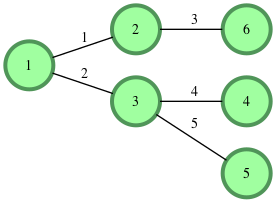

In this case, node numbers match their weights for convenience. The graph is shown below.

### Exemplo2
Seja uma árvore onde os pesos dos nós são seus próprios números:
*   **Soma Total da Árvore**: $1 + 2 + 3 + 4 + 5 + 6 = 21$
*   Se cortarmos a aresta que isola o nó `2`, e a subárvore enraizada em `2` tem soma $9$, a outra parte terá $21 - 9 = 12$.
*   **Diferença**: $|12 - 9| = 3$.

## 📤 Exemplo de Entrada
```text
6
100 200 100 500 100 600
1 2
2 3
2 5
4 5
5 6
```

## 📤 Exemplo de Saída
```text
400
```


In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'cutTheTree' function below.
#
# The function is expected to return an INTEGER.
# The function accepts following parameters:
#  1. INTEGER_ARRAY data
#  2. 2D_INTEGER_ARRAY edges
#
from typing import Tuple, List
from collections import defaultdict
sys.setrecursionlimit(10**5 + 1)

def cutTheTree(data, edges):
    total_sum = sum(data)
    adjacency_list = defaultdict(list)

    for u, v in edges:
        adjacency_list[u].append(v)
        adjacency_list[v].append(u)
    
    subtree_sums = []
    
    def dfs(node:int, parent:int) -> int:
        current_sum = data[node - 1]
        
        for neighbor in adjacency_list[node]:
            if neighbor == parent:
                continue
            current_sum = current_sum + dfs(neighbor, node)
        
        subtree_sums.append(current_sum)
        return current_sum

    dfs(1, -1)
    
    min_diff = float('inf')
    for subtree_sum in subtree_sums:
        tree_remaning = total_sum - subtree_sum
        diff = abs(subtree_sum - tree_remaning)
        min_diff = min(min_diff,diff)
    return min_diff
        
    
if __name__ == '__main__':
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    n = int(input().strip())

    data = list(map(int, input().rstrip().split()))

    edges = []

    for _ in range(n - 1):
        edges.append(list(map(int, input().rstrip().split())))

    result = cutTheTree(data, edges)

    fptr.write(str(result) + '\n')

    fptr.close()
